# Tiny Transformer Laboratory

**Educational notebook** — step-by-step inspection of the tiny decoder-only Transformer
trained on the Lost Melbourne corpus.

> **Important**: All generated text in this notebook is labelled
> *Tiny Transformer experimental generation — not a factual historical answer*.
> The model is too small and its corpus too limited to be a reliable historical source.
> Use the retrieval answerer (`scripts/answer_query.py`) for evidence-grounded responses.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import torch
import matplotlib.pyplot as plt
import matplotlib

from model import TinyTransformer, TransformerConfig
from tokenization import BPETokenizer

print('PyTorch:', torch.__version__)
print('Matplotlib:', matplotlib.__version__)

PyTorch: 2.9.1
Matplotlib: 3.10.9


## 1. Load the trained model

**Simple language:** We load the best checkpoint saved during training.

**Technical:** The checkpoint stores both the model weights (a `state_dict`) and the
configuration used to build the architecture.  We reconstruct the exact same network
before loading the weights.

In [2]:
CKPT = REPO_ROOT / 'artifacts' / 'checkpoints' / 'bpe_small_ctx128_v2' / 'best.pt'
model, payload = TinyTransformer.load_checkpoint(CKPT, device='cpu')
model.eval()
cfg = model.cfg

print(f'Config    : {cfg.param_summary()}')
print(f'Parameters: {model.count_parameters():,}')
print(f'Step      : {payload["step"]}   Val loss: {payload["val_loss"]:.4f}')

Config    : layers=2  heads=4  embed=128  ff=512  ctx=128  vocab=1065
Parameters: 548,480
Step      : 3000   Val loss: 3.9690


## 2. Tokenisation

**Simple language:** We break a sentence into small pieces (tokens) before the model
can process it.  Our BPE tokenizer merges common character sequences into single tokens,
so common words like "the" or "Melbourne" might be a single token.

**Technical:** The vocabulary has 1,065 tokens, built by 1,000 Byte Pair Encoding merges
on the 137,535-token training set.  Each word is segmented into sub-word units; the
end-of-word marker `</w>` signals word boundaries.

In [3]:
TOK_PATH = REPO_ROOT / 'data' / 'model' / 'tokenizers' / 'bpe_tokenizer.json'
tokenizer = BPETokenizer.load(TOK_PATH)

sentence = 'Flinders Street Station was built in 1905'
ids = tokenizer.encode(sentence)
subwords = [tokenizer._id_to_token.get(i, '<UNK>') for i in ids]

print(f'Input    : {sentence!r}')
print(f'Token ids: {ids}')
print(f'Subwords : {subwords}')
print(f'Decoded  : {tokenizer.decode(ids)!r}')
print(f'Vocab size: {tokenizer.vocab_size}')

Input    : 'Flinders Street Station was built in 1905'
Token ids: [92, 171, 168, 295, 1013, 333, 575, 22, 30, 21, 26]
Subwords : ['Flinders</w>', 'Street</w>', 'St', 'ation</w>', 'was</w>', 'built</w>', 'in</w>', '1</w>', '9</w>', '0</w>', '5</w>']
Decoded  : 'Flinders Street Station was built in 1 9 0 5'
Vocab size: 1065


## 3. Token embeddings

**Simple language:** Each token is converted into a list of 128 numbers.  These numbers
are the model's initial representation of the token's meaning.

**Technical:** The embedding matrix has shape `(vocab_size, embed_dim)` = `(1065, 128)`.
Looking up a token id gives one row of this matrix — a learned 128-dimensional vector.

In [4]:
input_ids = torch.tensor([ids], dtype=torch.long)   # shape (1, T)
T = input_ids.shape[1]

with torch.no_grad():
    tok_emb = model.token_emb(input_ids)            # (1, T, 128)

print(f'Input shape  : {input_ids.shape}')
print(f'Token emb    : {tok_emb.shape}  (batch=1, seq_len={T}, embed=128)')
print(f'First token embedding (first 8 dims): {tok_emb[0, 0, :8].tolist()}')

Input shape  : torch.Size([1, 11])
Token emb    : torch.Size([1, 11, 128])  (batch=1, seq_len=11, embed=128)
First token embedding (first 8 dims): [0.1014571487903595, 0.14366725087165833, 0.005254254676401615, 0.1022980809211731, -0.10951608419418335, -0.09467920660972595, 0.06978332996368408, -0.040323853492736816]


## 4. Positional embeddings

**Simple language:** The model does not read tokens one by one — it sees all of them at
once.  Positional embeddings add position information so the model knows which token is
first, second, third, and so on.

**Technical:** A learned positional embedding matrix of shape `(context_len, embed_dim)`
= `(128, 128)`.  Each position `t` in `[0, 127]` has its own 128-dimensional vector.
These are added to the token embeddings before entering the first Transformer block.

Position embedding shape: torch.Size([1, 11, 128])
Combined (tok + pos)    : torch.Size([1, 11, 128])


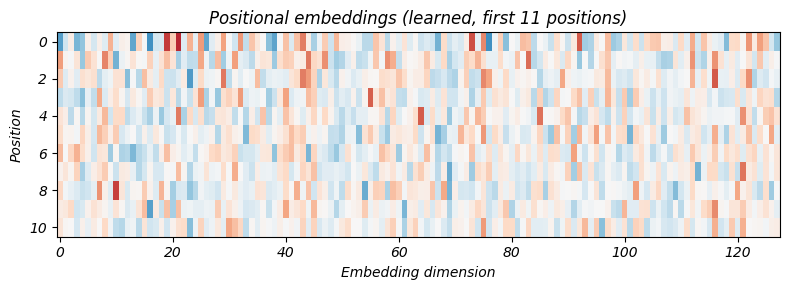

In [5]:
positions = torch.arange(T).unsqueeze(0)            # (1, T)

with torch.no_grad():
    pos_emb = model.pos_emb(positions)              # (1, T, 128)
    x = tok_emb + pos_emb                           # (1, T, 128)

print(f'Position embedding shape: {pos_emb.shape}')
print(f'Combined (tok + pos)    : {x.shape}')

# Show that embeddings differ across positions even for the same token
fig, ax = plt.subplots(figsize=(8, 3))
ax.imshow(pos_emb[0].numpy(), aspect='auto', cmap='RdBu', vmin=-0.1, vmax=0.1)
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Position')
ax.set_title('Positional embeddings (learned, first {} positions)'.format(T))
plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'reports' / 'pos_embeddings.png'), dpi=100)
plt.show()

## 5. Causal attention mask

**Simple language:** When predicting the next word, the model is only allowed to look at
words that came before it — not future words.  The mask blocks out those future positions
(shown in dark below).

**Technical:** An upper-triangular boolean mask of shape `(T, T)`.  Positions where the
mask is `True` are filled with `-inf` before the softmax, making their attention weight
exactly zero after the exponential operation.

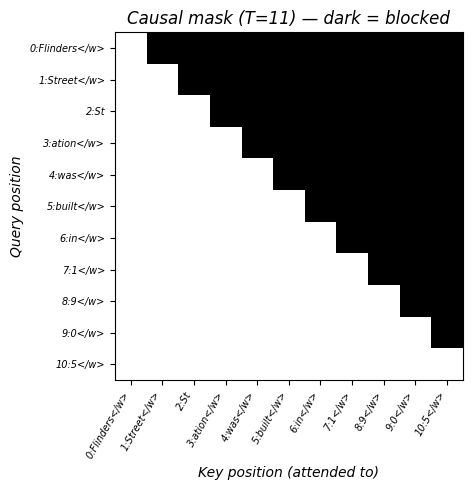

In [6]:
from model.attention import CausalSelfAttention

attn_layer = model.blocks[0].attn
mask = attn_layer.make_causal_mask(T, device=torch.device('cpu'))  # (T, T)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mask.float().numpy(), cmap='Greys', vmin=0, vmax=1)
ax.set_xlabel('Key position (attended to)')
ax.set_ylabel('Query position')
ax.set_title(f'Causal mask (T={T}) — dark = blocked')
labels = [f'{i}:{sw}' for i, sw in enumerate(subwords)]
ax.set_xticks(range(T)); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(T)); ax.set_yticklabels(labels, fontsize=7)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'reports' / 'causal_mask.png'), dpi=100)
plt.show()

## 6. Attention weights — one head

**Simple language:** Each position in the sequence decides which earlier positions to
focus on.  The attention weights (from 0 to 1) say how much focus is placed on each
earlier word.  We look at one head from the first Transformer block.

**Technical:** Attention weights are computed as `softmax((QK^T) / sqrt(d_k))` masked
by the causal mask.  We extract `weights[0, head_idx, :, :]` — shape `(T, T)` —
from the first block and display head 0.  Note that attention patterns are only one
of many explanations for model behaviour and should not be over-interpreted.

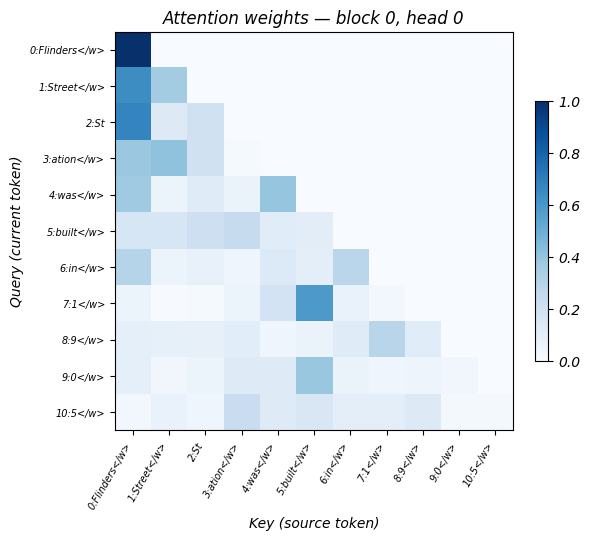

Attention weight matrix shape: (11, 11)
Row sum (should be ~1.0 for attended positions): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
with torch.no_grad():
    out = model(input_ids, return_attn_weights=True)
    weights_block0 = out['attn_weights'][0]   # (1, n_heads, T, T)

head_idx = 0
w = weights_block0[0, head_idx].numpy()      # (T, T)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(w, cmap='Blues', vmin=0, vmax=w.max())
ax.set_title(f'Attention weights — block 0, head {head_idx}')
ax.set_xlabel('Key (source token)')
ax.set_ylabel('Query (current token)')
ax.set_xticks(range(T)); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(T)); ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'reports' / 'attention_weights.png'), dpi=100)
plt.show()

print(f'Attention weight matrix shape: {w.shape}')
print(f'Row sum (should be ~1.0 for attended positions): {w.sum(axis=1).round(3)}')

## 7. Logits and next-token probabilities

**Simple language:** After the Transformer processes all tokens, it produces a score for
every word in the vocabulary.  These scores (logits) are converted to probabilities.
The token with the highest probability is the model's best guess for what comes next.

**Technical:** The language model head projects `(B, T, embed_dim) → (B, T, vocab_size)`.
For position `t`, `logits[0, t, :]` are the unnormalised scores over 1,065 BPE tokens.
`softmax(logits)` gives a probability distribution.  At the last position we look at
the top-10 predicted next tokens.

In [8]:
import torch.nn.functional as F

logits_last = out['logits'][0, -1, :]          # (vocab_size,)
probs_last  = F.softmax(logits_last, dim=-1)   # (vocab_size,)

top_k = 10
top_probs, top_ids = torch.topk(probs_last, top_k)

print(f'Logit shape: {out["logits"].shape}')
print(f'\nTop-{top_k} predicted next tokens after "{sentence}":')
print(f'  (Tiny Transformer experimental generation — not a factual historical answer)')
print(f'{"Token":<30} {"ID":>6}  {"Probability":>12}')
print('-' * 52)
for prob, tid in zip(top_probs.tolist(), top_ids.tolist()):
    token = tokenizer._id_to_token.get(tid, '<UNK>')
    print(f'{token:<30} {tid:>6}  {prob:>12.4f}')

Logit shape: torch.Size([1, 11, 1065])

Top-10 predicted next tokens after "Flinders Street Station was built in 1905":
  (Tiny Transformer experimental generation — not a factual historical answer)
Token                              ID   Probability
----------------------------------------------------
.</w>                              19        0.1556
0</w>                              21        0.1112
,</w>                              17        0.1038
9</w>                              30        0.0714
and</w>                           253        0.0529
8</w>                              29        0.0481
3</w>                              24        0.0404
1</w>                              22        0.0274
to</w>                            957        0.0257
5</w>                              26        0.0239


## 8. What did the model learn — and what it did not

**Simple language:**

What it learned:
- Basic English word order and punctuation patterns
- Melbourne place names and years (1850s, 1905, Flinders Street, Carlton)
- Some heritage/history vocabulary (demolished, heritage, built, railway)
- General sentence structure

What it did NOT learn:
- Factual accuracy — it mixes real and invented statements
- Long-range coherence — greedy generation quickly loops on short phrases
- When to stop — without a strong EOS signal it continues indefinitely
- Historical truth — it cannot be trusted as a historical source

**Technical:**

- Trained on only ~137K BPE tokens from 19 documents
- 548K parameters: enough to memorise surface patterns, not enough to generalise
- Validation perplexity 53 (BPE) vs bigram baseline 70 — model learns beyond bigrams
- Char model reaches perplexity 7.3 (a different, character-level measurement)
- Overfitting clearly visible in the 4-layer model (train=0.96, val=5.36 at step 3000)
- The retrieval system (Phase 3) is the correct tool for evidence-grounded questions
- A production generator would require a pretrained LLM + retrieval + claim validation

**Why the tiny Transformer is still useful for learning:**

It demonstrates every component of the architecture from scratch — embeddings, causal
masking, multi-head attention, feed-forward layers, residuals, layer norm, and next-token
prediction — in a codebase small enough to read in one sitting.  The overfitting and
loop behaviour are genuine and instructive failures of small models on small data.